In [1]:
# Exp4.py
!pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
# Import all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Download and load boston housing dataset using kagglehub
import kagglehub
import os

path = kagglehub.dataset_download("vikrishnan/boston-house-prices")
print("Path to dataset files:", path)

# Load dataset
df = pd.read_csv(os.path.join(path, "housing.csv"),
                    header=None,
                    sep='\s+',
                    names=['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
                    'DIS','RAD','TAX','PTRATIO','B','LSTAT','PRICE'])

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Path to dataset files: /Users/bhumikajawale/.cache/kagglehub/datasets/vikrishnan/boston-house-prices/versions/1

Dataset loaded successfully!
Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  



Column	Description
crim	Per capita crime rate by town
zn	Residential land zoned for large lots
indus	Proportion of non-retail business acres
chas	Charles River dummy variable (1 if near river, else 0)
nox	Nitric oxide concentration
rm	Average number of rooms per dwelling
age	Proportion of old owner-occupied units
dis	Distance to employment centers
rad	Accessibility to radial highways
tax	Property tax rate
ptratio	Pupil-teacher ratio by town
b	Proportion related to Black population index
lstat	Percentage of lower status population
medv	Median value of owner-occupied homes


In [9]:
# Perform train test split
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Create model variable and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Perform prediction and calculate error
y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MSE: 24.29
R2 Score: 0.67


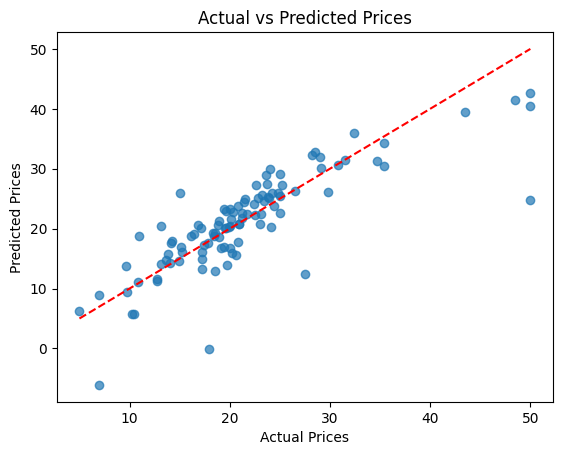

In [13]:
# Plot Actual & Predicted rpice with linear regression line
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [14]:
sample_data = X_test.iloc[0:1]

predicted_price = model.predict(sample_data)

print("Predicted House Price:", predicted_price[0])
print("Actual House Price:", y_test.iloc[0])

Predicted House Price: 28.99672361982504
Actual House Price: 23.6
